# Occupational mobility and automation, on US data

Runs `skabm.behaviour.labour` — del Rio-Chanona, Mealy, Beguerisse-Díaz, Lafond & Farmer (2021),
*Occupational mobility and automation: a data-driven network model*, J. R. Soc. Interface
18(174):20200898 — against the paper's own inputs.

The model itself is eight SPARQL rules in `skabm/behaviour/labour.py`. Everything in this
notebook is specific to *this dataset*: getting one deposit's CSVs into the two populations the
rules expect, and plotting what comes out. None of it belongs in the library, and the test suite
never touches it — `tests/test_labour.py` runs entirely on synthetic networks.

**Data.** Zenodo record 4453162, CC BY 4.0. The deposit is a single 242 MB zip and we need six
files totalling ~5 MB, so rather than downloading it we hand `zipfile` a file object that reads
over HTTP range requests. The stdlib then does the rest — index, offsets, decompression — and
pulls the members out in five requests. Files land in `notebooks/data/` (gitignored); rerun and
it reads from there.

In [1]:
import io
import math
import zipfile
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import polars as pl

from skabm.behaviour.labour import (
    LABOUR_UDFS,
    LABOUR_UPDATE_RULES,
    labour_params,
    occupations,
    reallocate_demand,
)
from skabm.rules import _PREFIXES, EX_NS, dbl
from skabm.simulation import RDFSimulator

ZENODO = "https://zenodo.org/api/records/4453162/files/online_repository.zip/content"
WANTED = [
    "occupational_mobility_network.csv",
    "ipums_employment_2016.csv",
    "ipums_variables.csv",
    "Total_unemployment_BLS1950-2018.csv",
    "vacancy_rateDec2000.csv",
]
DATA = Path("data")
DATA.mkdir(exist_ok=True)


class HttpFile(io.RawIOBase):
    """A seekable file over HTTP range requests, so zipfile can open a remote archive."""

    def __init__(self, url, client):
        self.url, self.client, self.pos = url, client, 0
        self.size = int(client.head(url).headers["content-length"])

    def readable(self):
        return True

    def seekable(self):
        return True

    def tell(self):
        return self.pos

    def seek(self, offset, whence=io.SEEK_SET):
        base = {io.SEEK_SET: 0, io.SEEK_CUR: self.pos, io.SEEK_END: self.size}[whence]
        self.pos = base + offset
        return self.pos

    def readinto(self, buffer):
        n = min(len(buffer), self.size - self.pos)
        if n <= 0:
            return 0
        response = self.client.get(
            self.url, headers={"Range": f"bytes={self.pos}-{self.pos + n - 1}"}
        )
        response.raise_for_status()
        buffer[:n] = response.content
        self.pos += n
        return n


missing = [name for name in WANTED if not (DATA / name).exists()]
if missing:
    with httpx.Client(follow_redirects=True, timeout=120.0) as client:
        remote = io.BufferedReader(HttpFile(ZENODO, client), buffer_size=1 << 20)
        with zipfile.ZipFile(remote) as archive:
            members = {Path(n).name: n for n in archive.namelist()}
            for name in missing:
                (DATA / name).write_bytes(archive.read(members[name]))
    print(f"fetched {len(missing)} files from the Zenodo archive")

csv = {name: DATA / name for name in WANTED}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


# Shared across the analysis cells below.  `map_population` owns bare-id -> IRI on the
# way in; this is the inverse, and the only place the notebook needs to know
# that agent IRIs are `<EX_NS + id>`.
AGENT_ID = pl.col("agent").str.strip_chars("<>").str.strip_prefix(EX_NS).alias("id")


def snapshot(sim):
    """Per-occupation state from a live simulator, keyed by bare occupation id.

    `sim.extract()` is derived from the rules: the columns are exactly the
    predicates LABOUR_UPDATE_RULES read or write, so nothing here lists them.
    """
    return sim.extract().with_columns(AGENT_ID)


def rates(row):
    """Aggregate stocks and the three headline rates (%), as one row.

    The four stocks are yielded rather than computed: a SUM over an occupation
    predicate is exactly what the rules imply, so only the rates are written
    here.  Note the denominators differ: unemployment is a share of the labour
    force (e + u), vacancies a share of posted positions (e + v).
    """
    e, u, v, ltu = (
        row[f"sig__SUM__Occupation__{name}"]
        for name in ("employment", "unemployment", "vacancies", "ltu")
    )
    return {
        "e": e,
        "u": u,
        "v": v,
        "ltu": ltu,
        "u_rate": 100 * u / (e + u),
        "v_rate": 100 * v / (e + v),
        "ltu_rate": 100 * ltu / (e + u),
    }


def demand_level(t, amplitude=0.05, period=40):
    """Aggregate demand multiplier at tick t - one business cycle per `period`."""
    return 1.0 + amplitude * math.sin(2 * math.pi * t / period)


## The occupational mobility network

The deposited matrix is already *A* of eq. 21, not raw transition counts: rows sum to 1 and the
diagonal is a constant 0.5503 — the paper's fitted stay probability `r`. (`labour.mobility_network`
applies eqs. 20–21 and is for raw CPS counts, so it is *not* used here.)

The rules want it as an `Edge` population: one agent per edge with `src` / `dst` links and a
`weight`. Zeros are dropped — an absent edge and a zero-weight edge mean the same thing to the
rules, and the difference is 143k triples.

In [2]:
n = 464
matrix = pl.read_csv(
    csv["occupational_mobility_network.csv"],
    has_header=False,
    new_columns=[f"c{j}" for j in range(n)],
)
edges = (
    matrix.with_row_index("i")
    .unpivot(index="i", variable_name="j", value_name="weight")
    .with_columns(pl.col("j").str.strip_prefix("c").cast(pl.UInt32))
    .filter(pl.col("weight") > 0)
    .select(
        id=pl.format("edge_{}_{}", pl.col("i"), pl.col("j")),
        src=pl.format("occ_{}", pl.col("i")),
        dst=pl.format("occ_{}", pl.col("j")),
        weight="weight",
    )
)

row_totals = edges.group_by("src").agg(t=pl.col("weight").sum())["t"]
diagonal = edges.filter(pl.col("src") == pl.col("dst"))["weight"]
print(f"{len(edges):,} weighted directed edges over {edges['src'].n_unique()} occupations")
print(f"row sums   {row_totals.min():.6f} - {row_totals.max():.6f}   (should be 1)")
print(f"diagonal   {diagonal.min():.4f} - {diagonal.max():.4f}   (paper: r = 0.55)")

72,258 weighted directed edges over 464 occupations
row sums   1.000000 - 1.000000   (should be 1)
diagonal   0.5503 - 0.5503   (paper: r = 0.55)


## Occupations

2016 IPUMS-CPS employment, joined to the Frey–Osborne probability of computerization. Row order
is shared across the deposit's files, so the index is the occupation id.

`labour.occupations` seeds the state the rules need (unemployed pool, vacancies, flow and
duration accumulators). Target demand starts flat — the automation scenario is installed later,
after the market has settled.

In [3]:
attributes = (
    pl.read_csv(csv["ipums_employment_2016.csv"])
    .select(
        row=pl.col("").cast(pl.UInt32),
        title="ipums_ordered_occ_titles",
        classification="ACS_broad_classification",
        employment="IPUMS_CPS_av_monthly_employment_whole_period",
    )
    .join(
        pl.read_csv(csv["ipums_variables.csv"]).select(
            row=pl.col("id").cast(pl.UInt32),
            frey_osborne="auto_prob_average",
            median_earnings="median_earnings",
        ),
        on="row",
    )
    .with_columns(id=pl.format("occ_{}", pl.col("row")))
    .sort("row")
)

occ = occupations(attributes, unemployment_rate=0.05)
clock = pl.DataFrame({"id": ["clock"], "t": [0.0]})
labour_force = occ["employment"].sum() + occ["unemployment"].sum()
print(f"{len(occ)} occupations, labour force {labour_force / 1e6:.1f} M")
attributes.select("title", "employment", "frey_osborne").sort(
    "frey_osborne", descending=True
).head(5)

464 occupations, labour force 146.5 M


title,employment,frey_osborne
str,f64,f64
"""insurance underwriters""",105854.188788,0.99
"""tax preparers""",105913.719691,0.99
"""library technicians""",37430.842739,0.99
"""telemarketers""",82323.051339,0.99
"""new accounts clerks""",28201.981694,0.99


## 1. Burn-in

Flat target demand until the market settles at its natural rate. The paper does the same before
shocking anything.

In [4]:
NEVER = 1e6  # a shock_start far enough away that the S-curve stays dormant

sim = RDFSimulator(
    init_rules=(),
    update_rules=LABOUR_UPDATE_RULES,
    params={**labour_params, "shock_start": NEVER},
    udfs=LABOUR_UDFS,
    n_periods=60,
)
*_, settled = sim.fit_iter({"Occupation": occ, "Edge": edges, "Clock": clock})

steady = rates(settled)
print(
    f"steady state: u={steady['u_rate']:.2f}%  "
    f"v={steady['v_rate']:.2f}%  ltu={steady['ltu_rate']:.2f}%"
)
print("paper: initial aggregate unemployment rate about 5%")


steady state: u=5.26%  v=2.94%  ltu=2.04%
paper: initial aggregate unemployment rate about 5%


## 2. The Beveridge curve

The macro validation (paper, fig. 3). Cycling *aggregate* demand up and down should trace a
downward-sloping relation between unemployment and vacancies: when vacancies are plentiful, the
unemployed match faster. This is a business cycle, not automation.

Each tick scales target demand by one step of a sinusoid — a `model_.update` intervention on
structure between passes, with `warm_start=True` continuing the same world.

In [5]:
sim.set_params(n_periods=1, warm_start=True)

curve = []
for tick in range(80):
    # Only `demand_init` moves: with the shock dormant, `target_demand` returns
    # ?di untouched, and cell 12 overwrites `demand_final` wholesale anyway.
    ratio = demand_level(tick + 1) / demand_level(tick)
    sim.model_.update(
        _PREFIXES
        + f"""
        DELETE {{ ?o def:demand_init ?d0 }}
        INSERT {{ ?o def:demand_init ?d1 }}
        WHERE {{
            ?o a ex:Occupation ; def:demand_init ?d0 .
            BIND(?d0 * {dbl(ratio)} AS ?d1)
        }}"""
    )
    *_, row = sim.fit_iter()
    curve.append(rates(row))

curve = pl.DataFrame(curve).with_columns(tick=pl.int_range(pl.len()))


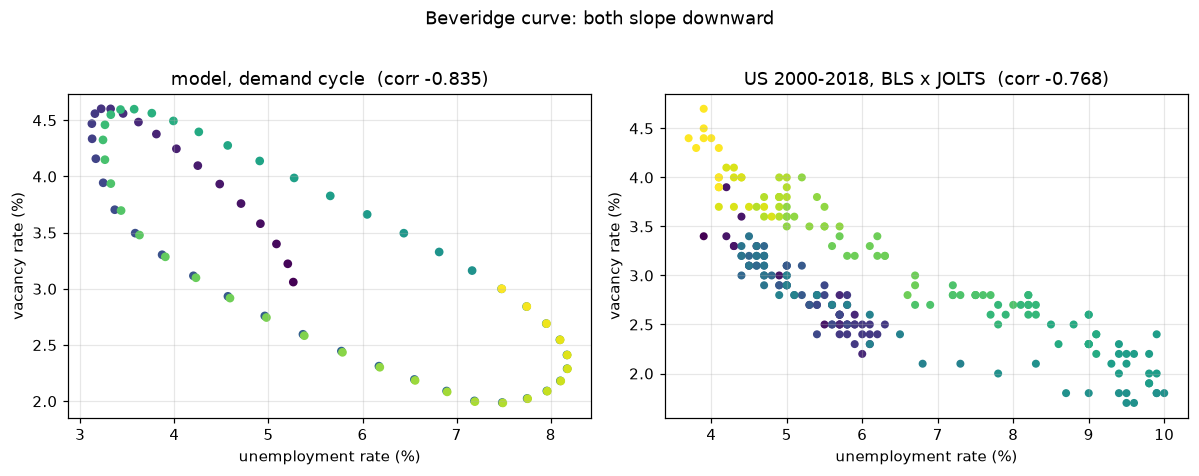

In [6]:
months = {m: i + 1 for i, m in enumerate(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)}
actual = (
    pl.read_csv(csv["Total_unemployment_BLS1950-2018.csv"])
    .unpivot(index="Year", variable_name="month_name", value_name="u_rate")
    .with_columns(
        year="Year",
        month=pl.col("month_name").replace_strict(months, return_dtype=pl.Int64),
    )
    .drop_nulls("u_rate")
    .join(
        pl.read_csv(csv["vacancy_rateDec2000.csv"]).select(
            year="Year",
            month=pl.col("Period").str.strip_prefix("M").cast(pl.Int64),
            v_rate="JobOpenings",
        ),
        on=["year", "month"],
    )
    .sort("year", "month")
)

model_corr = curve.select(pl.corr("u_rate", "v_rate")).item()
actual_corr = actual.select(pl.corr("u_rate", "v_rate")).item()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(curve["u_rate"], curve["v_rate"], c=curve["tick"], cmap="viridis", s=22)
axes[0].set_title(f"model, demand cycle  (corr {model_corr:+.3f})")
axes[1].scatter(actual["u_rate"], actual["v_rate"], c=actual["year"], cmap="viridis", s=18)
axes[1].set_title(f"US 2000-2018, BLS x JOLTS  (corr {actual_corr:+.3f})")
for ax in axes:
    ax.set_xlabel("unemployment rate (%)")
    ax.set_ylabel("vacancy rate (%)")
fig.suptitle("Beveridge curve: both slope downward", y=1.02)
fig.tight_layout()
plt.show()


## 3. The automation shock

Eq. 18: automation is a *reallocation*. Each occupation's hours fall by its automation level, the
surviving hours are shared equally across the whole workforce, and the resulting head-counts are
the new target demand — aggregate demand unchanged, its distribution moved. Target demand then
slides along the S-curve of eq. 19 over 30 years.

The cycle left the market mid-recovery, so settle it again first: the shock has to start from the
steady state.

In [7]:
sim.set_params(n_periods=40)
sim.fit()
before_shock = snapshot(sim)

scenario = (
    sim.model_.query(
        _PREFIXES
        + "SELECT ?agent ?demand_init WHERE "
        + "{ ?agent a ex:Occupation ; def:demand_init ?demand_init }"
    )
    .with_columns(AGENT_ID)
    .join(attributes.select("id", "frey_osborne"), on="id")
    .with_columns(
        demand_final=reallocate_demand(pl.col("demand_init"), pl.col("frey_osborne"))
    )
)
values = " ".join(
    f'(<{a.strip("<>")}> {dbl(d)})'
    for a, d in scenario.select("agent", "demand_final").iter_rows()
)
sim.model_.update(
    _PREFIXES
    + "DELETE { ?o def:demand_final ?f0 } INSERT { ?o def:demand_final ?f1 } "
    + f"WHERE {{ VALUES (?o ?f1) {{ {values} }} ?o def:demand_final ?f0 . }}"
)
sim.model_.update(
    _PREFIXES
    + "DELETE { ?c def:t ?t0 } INSERT { ?c def:t 0e0 } WHERE { ?c a ex:Clock ; def:t ?t0 }"
)
print(
    f"aggregate demand {scenario['demand_init'].sum() / 1e6:.1f} M -> "
    f"{scenario['demand_final'].sum() / 1e6:.1f} M   (unchanged: this is reallocation)"
)


aggregate demand 146.5 M -> 146.5 M   (unchanged: this is reallocation)


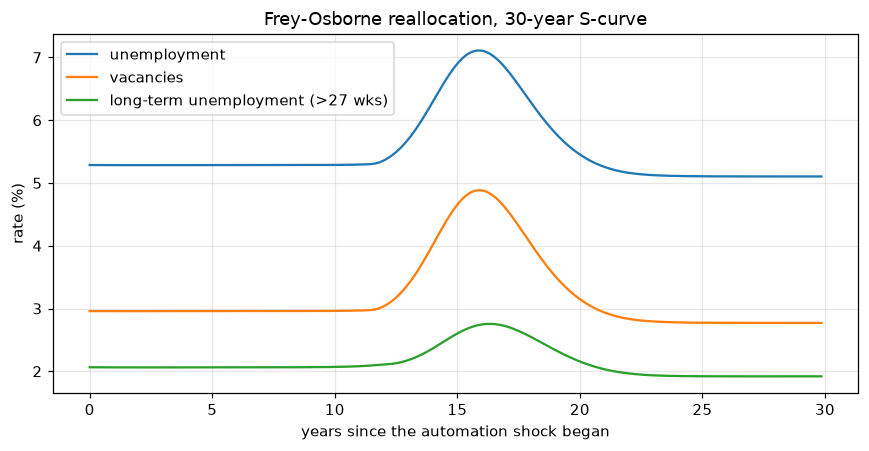

unemployment      5.29%  ->  peak 7.11%
long-term unempl. 2.06%  ->  peak 2.75%   (paper: 2.6% at peak)


In [8]:
step_years = labour_params["weeks_per_step"] / 52
shock_ticks = int(30 / step_years)
sim.set_params(n_periods=shock_ticks, params={**labour_params, "shock_start": 0.0})

path = []
for row in sim.fit_iter():
    path.append(rates(row))
path = pl.DataFrame(path).with_columns(years=pl.int_range(pl.len()) * step_years)

fig, ax = plt.subplots(figsize=(8, 4.2))
for column, label in [
    ("u_rate", "unemployment"),
    ("v_rate", "vacancies"),
    ("ltu_rate", "long-term unemployment (>27 wks)"),
]:
    ax.plot(path["years"], path[column], label=label)
ax.set_xlabel("years since the automation shock began")
ax.set_ylabel("rate (%)")
ax.set_title("Frey-Osborne reallocation, 30-year S-curve")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unemployment      {path['u_rate'][0]:.2f}%  ->  peak {path['u_rate'].max():.2f}%")
print(f"long-term unempl. {path['ltu_rate'][0]:.2f}%  ->  peak {path['ltu_rate'].max():.2f}%"
      "   (paper: 2.6% at peak)")


## 4. Which occupations, and why not just the risky ones

The paper's micro result (fig. 5). Note these are *rates* — a growing occupation ends up with more
long-term unemployed simply by being bigger, which says nothing about how hard it is to find work
there.

The correlation with automation risk is weak, and that is the finding: two occupations at the same
risk can move in opposite directions depending on whether the network gives their workers anywhere
to go.

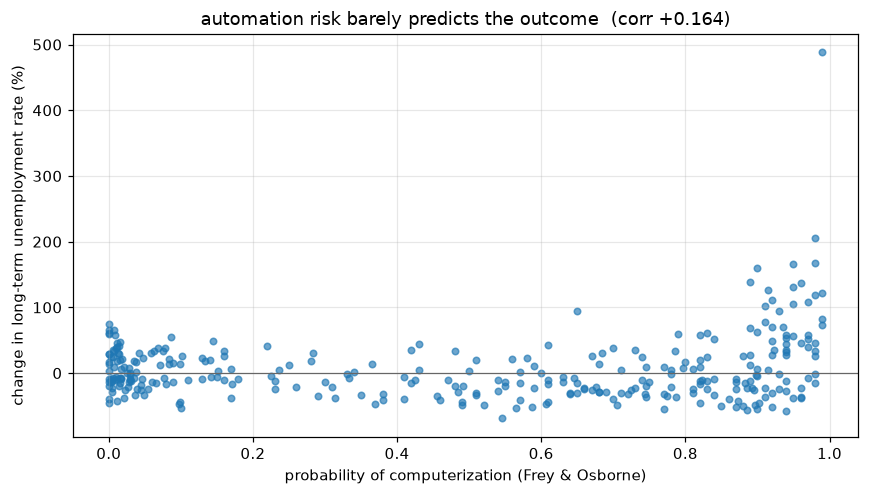

title,auto_risk,LTU%_pre,LTU%_post,change_%
str,f64,f64,f64,f64
"""insurance underwriters""",0.99,0.31,1.85,488.0
"""claims adjusters, appraisers, …",0.98,0.45,1.38,205.0
"""insurance claims and policy pr…",0.98,0.56,1.5,167.0
"""postal service clerks""",0.95,0.23,0.61,167.0
"""appraisers and assessors of re…",0.9,0.27,0.71,160.0
…,…,…,…,…
"""dishwashers""",0.77,0.9,0.41,-55.0
"""cashiers""",0.9,5.94,2.66,-55.0
"""cooks""",0.88,3.17,1.39,-56.0


In [9]:
after_shock = snapshot(sim)
# Re-evaluated against each frame, so the denominators are each side's own
# labour force -- that is the point: these are rates, not head-counts.
ltu_share = pl.col("ltu") / (pl.col("employment") + pl.col("unemployment"))
change = (
    before_shock.select(
        "id",
        ltu_before=ltu_share,
        force=pl.col("employment") + pl.col("unemployment"),
    )
    .join(after_shock.select("id", ltu_after=ltu_share), on="id")
    .join(attributes.select("id", "title", "frey_osborne"), on="id")
    .filter(pl.col("force") > 50_000)
    .with_columns(ltu_change=100 * (pl.col("ltu_after") / pl.col("ltu_before") - 1))
    .sort("ltu_change", descending=True)
)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(change["frey_osborne"], change["ltu_change"], s=18, alpha=0.65)
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("probability of computerization (Frey & Osborne)")
ax.set_ylabel("change in long-term unemployment rate (%)")
ax.set_title(
    "automation risk barely predicts the outcome  "
    f"(corr {change.select(pl.corr('ltu_change', 'frey_osborne')).item():+.3f})"
)
fig.tight_layout()
plt.show()

pl.concat([change.head(6), change.tail(6)]).select(
    pl.col("title").str.slice(0, 46),
    pl.col("frey_osborne").round(2).alias("auto_risk"),
    (100 * pl.col("ltu_before")).round(2).alias("LTU%_pre"),
    (100 * pl.col("ltu_after")).round(2).alias("LTU%_post"),
    pl.col("ltu_change").round(0).alias("change_%"),
)


In [10]:
band = change.filter(pl.col("frey_osborne").is_between(0.4, 0.7))
print(
    f"Among the {len(band)} occupations at comparable automation risk [0.4, 0.7], the change in\n"
    f"the long-term unemployment rate ranges {band['ltu_change'].min():+.0f}% to "
    f"{band['ltu_change'].max():+.0f}%."
)

Among the 61 occupations at comparable automation risk [0.4, 0.7], the change in
the long-term unemployment rate ranges -69% to +95%.
